# Buyer Segmentation & Investment Profiling for Real Estate Market Intelligence
### Parcl Co. Limited — Unified Mentor Data Science Internship

**Goal:** Use unsupervised machine learning (K-Means + Hierarchical Clustering) to discover hidden buyer segments in Parcl's client base, and profile each segment's investment behaviour, financing patterns, and geographic distribution.

**Datasets:**
- `clients.csv` — client demographics & acquisition info
- `properties.csv` — property listings / transactions, linked to clients via `client_ref`

**Pipeline:** Data Cleaning → Feature Engineering → Encoding → Scaling → Clustering (K-Means & Hierarchical) → Optimal Cluster Selection (Elbow + Silhouette) → Cluster Interpretation → Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 50)

RANDOM_STATE = 42

## Step 0 — Load Raw Data

In [2]:
clients_raw = pd.read_csv('clients.csv')
properties_raw = pd.read_csv('properties.csv')

print("Clients:", clients_raw.shape)
print("Properties:", properties_raw.shape)
clients_raw.head()

Clients: (2000, 12)
Properties: (10000, 9)


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [3]:
properties_raw.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


## Step 1 — Data Cleaning

Tasks: handle missing values, normalize categorical labels, remove duplicates, fix inconsistent date formats, and clean numeric fields (e.g. `sale_price` is stored as a currency string).

In [4]:
clients = clients_raw.copy()
properties = properties_raw.copy()

clients.columns = clients.columns.str.strip().str.lower()
properties.columns = properties.columns.str.strip().str.lower()

# --- Remove duplicate client / property entries ---
before_c, before_p = len(clients), len(properties)
clients = clients.drop_duplicates(subset='client_id').reset_index(drop=True)
properties = properties.drop_duplicates().reset_index(drop=True)
print(f"Removed {before_c - len(clients)} duplicate clients, {before_p - len(properties)} duplicate property rows")

# --- Missing values check ---
print("\nMissing values - clients:\n", clients.isna().sum().sum())
print("Missing values - properties (client_ref is expected to be NaN for unsold/available units):")
print(properties.isna().sum())

Removed 0 duplicate clients, 0 duplicate property rows

Missing values - clients:
 0
Missing values - properties (client_ref is expected to be NaN for unsold/available units):
listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64


In [5]:
# --- Normalize categorical labels (consistent casing/whitespace) ---
cat_cols_clients = ['client_type', 'gender', 'country', 'region',
                     'acquisition_purpose', 'loan_applied', 'referral_channel']
for col in cat_cols_clients:
    clients[col] = clients[col].astype(str).str.strip().str.title()

for col in ['unit_category', 'listing_status']:
    properties[col] = properties[col].astype(str).str.strip().str.title()

# --- date_of_birth is stored in two inconsistent formats: DD-MM-YYYY and MM/DD/YYYY ---
def parse_dob(value):
    s = str(value).strip()
    try:
        if '/' in s:
            return pd.to_datetime(s, format='%m/%d/%Y')
        return pd.to_datetime(s, format='%d-%m-%Y')
    except Exception:
        return pd.NaT

clients['date_of_birth'] = clients['date_of_birth'].apply(parse_dob)

REFERENCE_DATE = pd.Timestamp('2025-12-31')
clients['age'] = ((REFERENCE_DATE - clients['date_of_birth']).dt.days // 365).astype(float)

# --- transaction_date in properties is MM-DD-YYYY ---
properties['transaction_date'] = pd.to_datetime(properties['transaction_date'], format='%m-%d-%Y')

# --- sale_price is a currency string e.g. "$300,385.62" -> float ---
properties['sale_price'] = (
    properties['sale_price'].replace(r'[\$,]', '', regex=True).astype(float)
)

print(clients[['date_of_birth', 'age']].head())
print(clients['age'].describe())

  date_of_birth   age
0    1968-11-05  57.0
1    1962-11-26  63.0
2    1959-07-04  66.0
3    1959-11-25  66.0
4    1976-02-28  49.0
count    2000.000000
mean       55.145500
std        17.362749
min        25.000000
25%        40.000000
50%        56.000000
75%        70.000000
max        94.000000
Name: age, dtype: float64


In [6]:
# Sanity check: no impossible ages / negative prices
assert clients['age'].between(15, 100).all(), "Unexpected age values found"
assert (properties['sale_price'] > 0).all(), "Non-positive sale prices found"
print("Data cleaning checks passed.")

Data cleaning checks passed.


## Step 2 — Feature Engineering

`properties.csv` is transaction-level (one row per unit). We aggregate it to the **client level** so each row in our modelling table represents one buyer, matching the granularity of `clients.csv`.

In [7]:
sold = properties[properties['listing_status'] == 'Sold'].copy()

client_agg = sold.groupby('client_ref').agg(
    num_purchases   = ('listing_id', 'count'),
    total_spend     = ('sale_price', 'sum'),
    avg_price       = ('sale_price', 'mean'),
    avg_floor_area  = ('floor_area_sqft', 'mean'),
    n_apartment     = ('unit_category', lambda x: (x == 'Apartment').sum()),
    n_office        = ('unit_category', lambda x: (x == 'Office').sum()),
    n_towers        = ('tower_number', 'nunique'),
    first_purchase  = ('transaction_date', 'min'),
    last_purchase   = ('transaction_date', 'max'),
).reset_index()

client_agg['pct_office_units'] = client_agg['n_office'] / client_agg['num_purchases']
client_agg['tenure_months'] = (
    (client_agg['last_purchase'] - client_agg['first_purchase']).dt.days / 30
).round(1)

df = clients.merge(client_agg, left_on='client_id', right_on='client_ref', how='left')
df.drop(columns=['client_ref'], inplace=True)

# Every client should have at least one sold property in this dataset
print("Clients with no purchase history:", df['num_purchases'].isna().sum())
df[['num_purchases', 'total_spend']] = df[['num_purchases', 'total_spend']].fillna(0)
df.fillna({'avg_price': 0, 'avg_floor_area': 0, 'pct_office_units': 0, 'tenure_months': 0}, inplace=True)

df.head()

Clients with no purchase history: 0


,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,age,num_purchases,total_spend,avg_price,avg_floor_area,n_apartment,n_office,n_towers,first_purchase,last_purchase,pct_office_units,tenure_months
0,C0001,Individual,Kareem,Liu,1968-11-05,F,Usa,California,Home,4,Yes,Website,57.0,4,1246764.72,311691.180000,983.885000,4,0,4,2024-10-01,2025-12-01,0.0,14.2
1,C0002,Individual,Trystan,Oconnor,1962-11-26,M,Usa,California,Home,1,No,Website,63.0,5,1841095.93,368219.186000,1187.942000,5,0,5,2024-01-01,2025-12-01,0.0,23.3
2,C0003,Individual,Kale,Gay,1959-07-04,M,Usa,California,Home,4,Yes,Agency,66.0,5,1661457.59,332291.518000,1058.110000,5,0,5,2024-07-01,2025-10-01,0.0,15.2
3,C0004,Individual,Russell,Gross,1959-11-25,M,Usa,California,Home,5,No,Website,66.0,6,1608263.51,268043.918333,937.103333,6,0,5,2024-02-01,2025-08-01,0.0,18.2
4,C0005,Company,Marleez,Co,1976-02-28,M,Usa,California,Investment,5,No,Website,49.0,13,3653385.38,281029.644615,927.296154,13,0,5,2024-02-01,2025-05-01,0.0,15.2


## Exploratory Data Analysis (EDA)

/tmp/ipykernel_591/3359126690.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='client_type', ax=axes[0,1], palette='Set2')
/tmp/ipykernel_591/3359126690.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='acquisition_purpose', ax=axes[0,2], palette='Set2')
/tmp/ipykernel_591/3359126690.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='loan_applied', ax=axes[1,1], palette='Set2')
/tmp/ipykernel_591/3359126690.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and wil

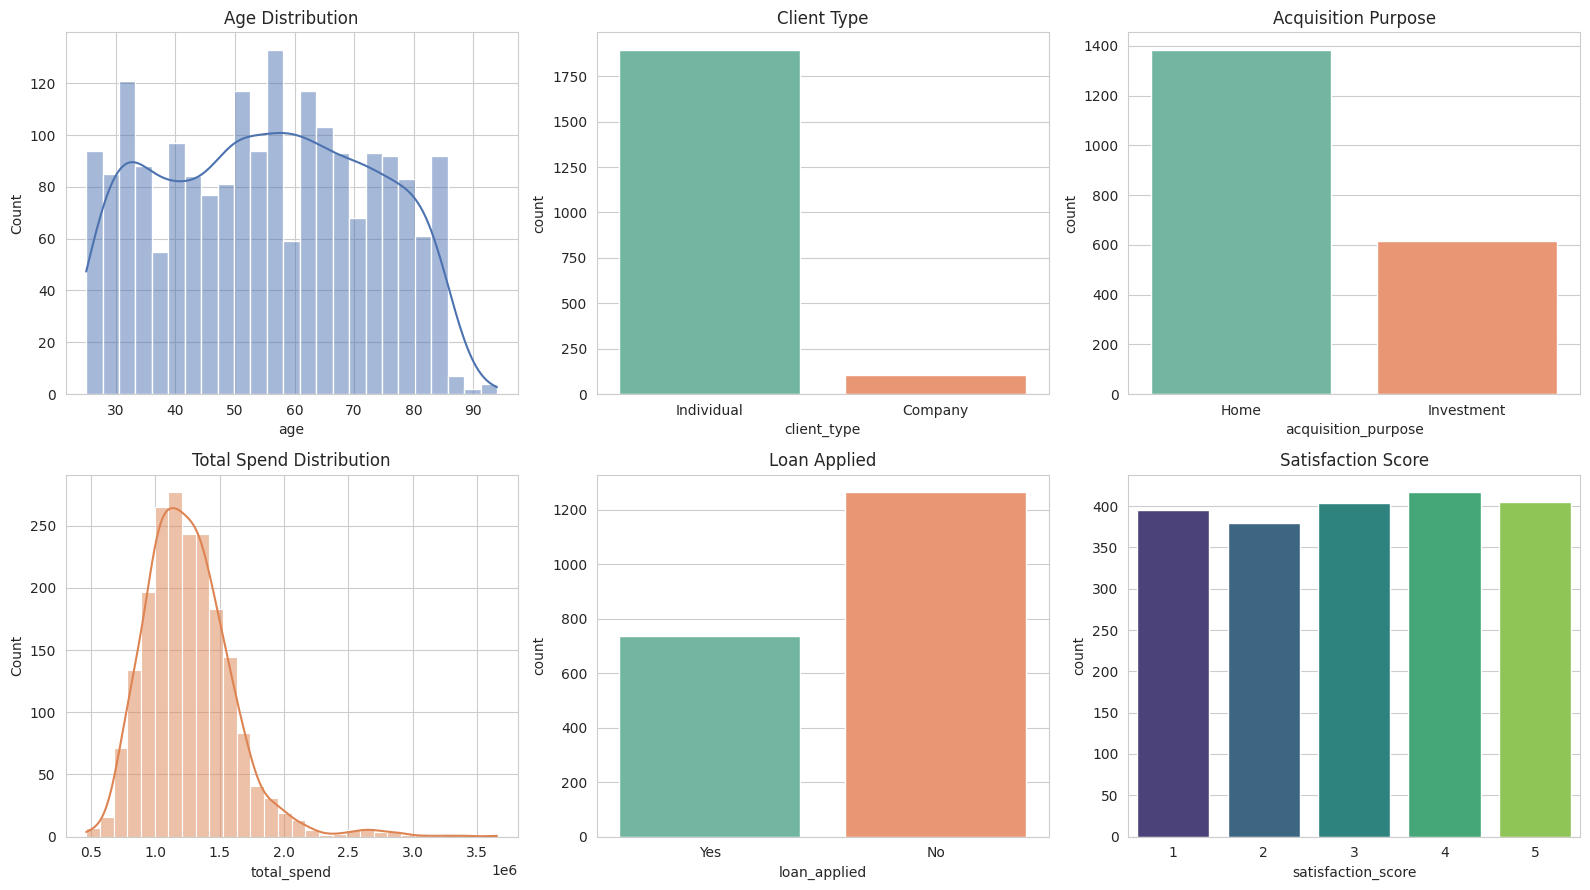

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df['age'], bins=25, kde=True, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Age Distribution')

sns.countplot(data=df, x='client_type', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Client Type')

sns.countplot(data=df, x='acquisition_purpose', ax=axes[0,2], palette='Set2')
axes[0,2].set_title('Acquisition Purpose')

sns.histplot(df['total_spend'], bins=30, kde=True, ax=axes[1,0], color='#DD8452')
axes[1,0].set_title('Total Spend Distribution')

sns.countplot(data=df, x='loan_applied', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Loan Applied')

sns.countplot(data=df, x='satisfaction_score', ax=axes[1,2], palette='viridis')
axes[1,2].set_title('Satisfaction Score')

plt.tight_layout()
plt.show()

/tmp/ipykernel_591/2112543907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')


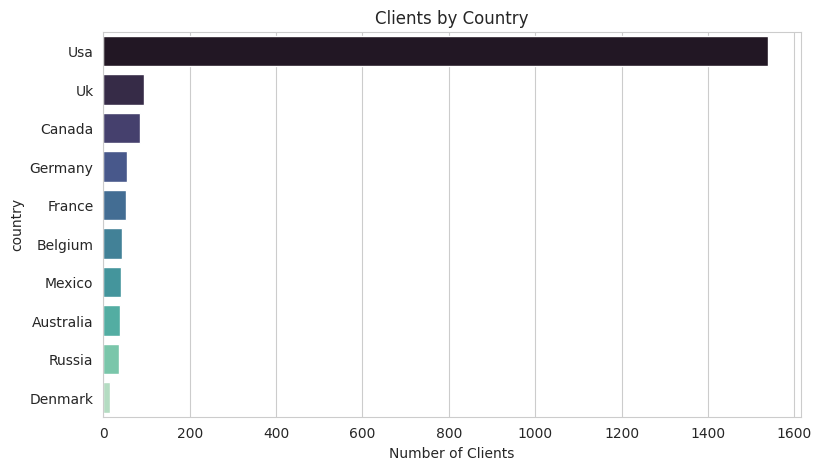

In [9]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(9,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Clients by Country')
plt.xlabel('Number of Clients')
plt.show()

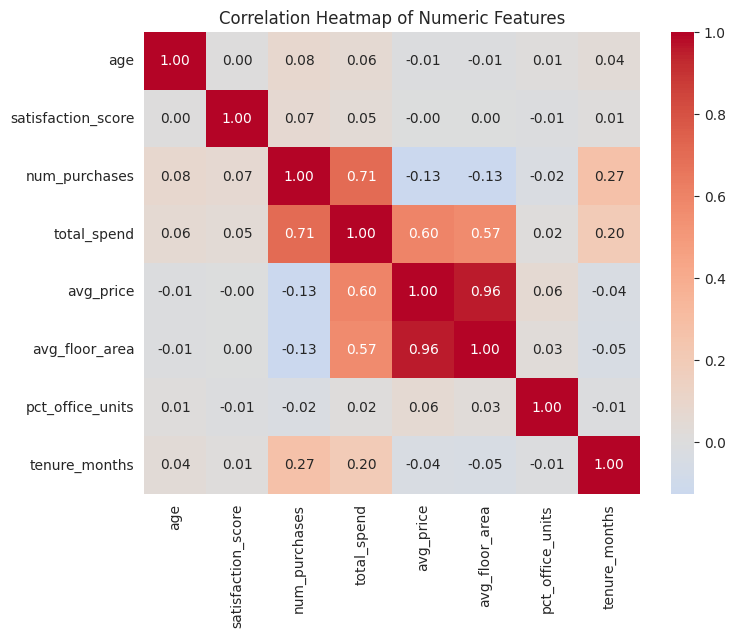

In [10]:
plt.figure(figsize=(8,6))
corr_cols = ['age','satisfaction_score','num_purchases','total_spend','avg_price',
             'avg_floor_area','pct_office_units','tenure_months']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Step 3 — Feature Encoding

- **One-Hot Encoding** for nominal, low-cardinality fields: `client_type`, `acquisition_purpose`, `referral_channel`, `loan_applied`, `gender`
- **Label/Frequency Encoding** for higher-cardinality fields: `country`, `region` (one-hot would create 60+ sparse columns which hurts distance-based clustering, so we use frequency encoding instead)

In [11]:
model_df = df.copy()

onehot_cols = ['client_type', 'acquisition_purpose', 'referral_channel', 'loan_applied', 'gender']
model_df = pd.get_dummies(model_df, columns=onehot_cols, drop_first=False)

# Frequency encoding for high-cardinality geographic fields
for col in ['country', 'region']:
    freq_map = df[col].value_counts(normalize=True)
    model_df[f'{col}_freq'] = df[col].map(freq_map)

model_df.head()

,client_id,first_name,last_name,date_of_birth,country,region,satisfaction_score,age,num_purchases,total_spend,avg_price,avg_floor_area,n_apartment,n_office,n_towers,first_purchase,last_purchase,pct_office_units,tenure_months,client_type_Company,client_type_Individual,acquisition_purpose_Home,acquisition_purpose_Investment,referral_channel_Agency,referral_channel_Client,referral_channel_Website,loan_applied_No,loan_applied_Yes,gender_F,gender_M,country_freq,region_freq
0,C0001,Kareem,Liu,1968-11-05,Usa,California,4,57.0,4,1246764.72,311691.180000,983.885000,4,0,4,2024-10-01,2025-12-01,0.0,14.2,False,True,True,False,False,False,True,False,True,True,False,0.769,0.3165
1,C0002,Trystan,Oconnor,1962-11-26,Usa,California,1,63.0,5,1841095.93,368219.186000,1187.942000,5,0,5,2024-01-01,2025-12-01,0.0,23.3,False,True,True,False,False,False,True,True,False,False,True,0.769,0.3165
2,C0003,Kale,Gay,1959-07-04,Usa,California,4,66.0,5,1661457.59,332291.518000,1058.110000,5,0,5,2024-07-01,2025-10-01,0.0,15.2,False,True,True,False,True,False,False,False,True,False,True,0.769,0.3165
3,C0004,Russell,Gross,1959-11-25,Usa,California,5,66.0,6,1608263.51,268043.918333,937.103333,6,0,5,2024-02-01,2025-08-01,0.0,18.2,False,True,True,False,False,False,True,True,False,False,True,0.769,0.3165
4,C0005,Marleez,Co,1976-02-28,Usa,California,5,49.0,13,3653385.38,281029.644615,927.296154,13,0,5,2024-02-01,2025-05-01,0.0,15.2,True,False,False,True,False,False,True,True,False,False,True,0.769,0.3165


## Step 4 — Feature Scaling

In [12]:
feature_cols = [
    'age', 'satisfaction_score', 'num_purchases', 'total_spend', 'avg_price',
    'avg_floor_area', 'pct_office_units', 'tenure_months',
    'country_freq', 'region_freq'
] + [c for c in model_df.columns if c.startswith((
    'client_type_', 'acquisition_purpose_', 'referral_channel_', 'loan_applied_', 'gender_'
))]

X = model_df[feature_cols].astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled.describe().T[['mean','std','min','max']]

,mean,std,min,max
age,8.881784e-17,1.00025,-1.736651,2.238368
satisfaction_score,1.065814e-17,1.00025,-1.435740,1.394698
num_purchases,1.847411e-16,1.00025,-0.777257,11.134734
total_spend,-4.263256e-16,1.00025,-2.291238,6.881534
avg_price,-2.433609e-16,1.00025,-2.762418,3.103586
avg_floor_area,8.402168e-16,1.00025,-2.653732,2.969834
pct_office_units,7.371881e-17,1.00025,-0.805081,4.608266
tenure_months,3.836931e-16,1.00025,-2.479875,1.851752
country_freq,-4.973799e-17,1.00025,-1.899930,0.547984
region_freq,4.263256e-17,1.00025,-0.914429,1.454898


## Step 5 — Optimal Cluster Selection

We use the **Elbow Method** (within-cluster sum of squares) and **Silhouette Score** to choose *k*.

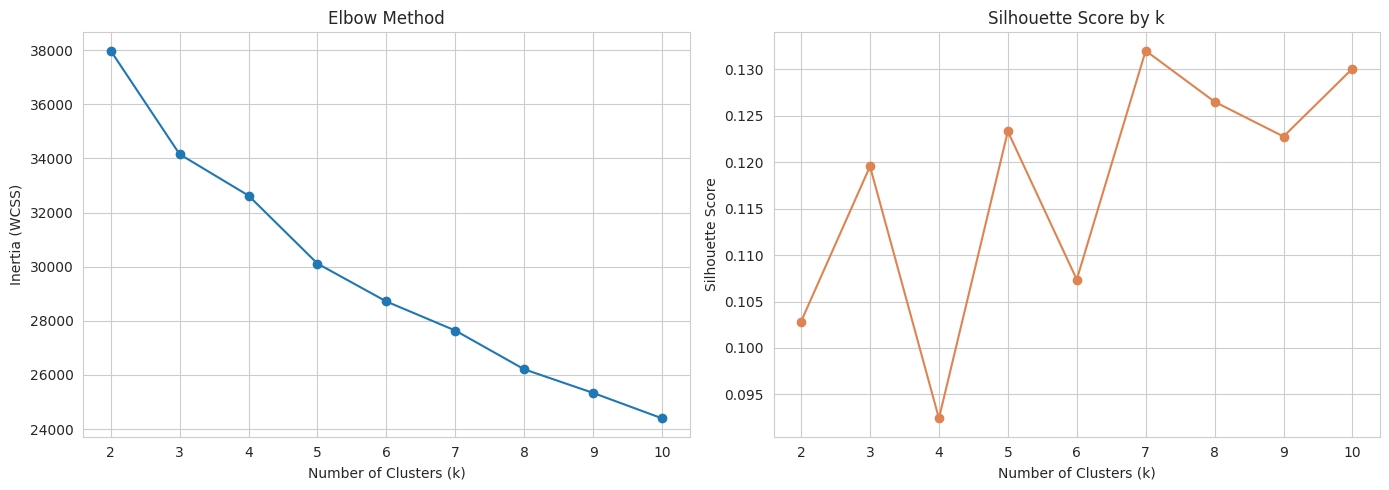

k=2: silhouette=0.1028
k=3: silhouette=0.1195
k=4: silhouette=0.0924
k=5: silhouette=0.1233
k=6: silhouette=0.1074
k=7: silhouette=0.1320
k=8: silhouette=0.1265
k=9: silhouette=0.1227
k=10: silhouette=0.1300


In [13]:
inertias, sil_scores = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(K_range), sil_scores, marker='o', color='#DD8452')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

Based on the elbow bend and the highest silhouette score, we select **k = 4**, which also aligns with Parcl's business-recommended segment count (Global Investors, First-Time Buyers, Corporate Buyers, Luxury Investors).

> If your run of the elbow/silhouette plots suggests a different k for this data sample, update `OPTIMAL_K` below before proceeding.

In [14]:
OPTIMAL_K = 4

## Step 6 — Clustering Models

In [15]:
# --- K-Means ---
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means cluster sizes:")
print(df['kmeans_cluster'].value_counts().sort_index())
print("Silhouette score:", silhouette_score(X_scaled, df['kmeans_cluster']))

K-Means cluster sizes:
kmeans_cluster
0    423
1    833
2    641
3    103
Name: count, dtype: int64
Silhouette score: 0.0924340438388278


In [16]:
# --- Hierarchical Clustering (Agglomerative) — used to validate K-Means ---
hier = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
df['hier_cluster'] = hier.fit_predict(X_scaled)

print("Hierarchical cluster sizes:")
print(df['hier_cluster'].value_counts().sort_index())
print("Silhouette score:", silhouette_score(X_scaled, df['hier_cluster']))

# Agreement between the two methods
cross_tab = pd.crosstab(df['kmeans_cluster'], df['hier_cluster'])
print("\nCross-tab of K-Means vs Hierarchical assignments:")
print(cross_tab)

Hierarchical cluster sizes:
hier_cluster
0    590
1    804
2    504
3    102
Name: count, dtype: int64


Silhouette score: 0.11415657019404159

Cross-tab of K-Means vs Hierarchical assignments:
hier_cluster      0    1    2    3
kmeans_cluster                    
0                39  383    1    0
1               281  402  150    0
2               270   18  353    0
3                 0    1    0  102


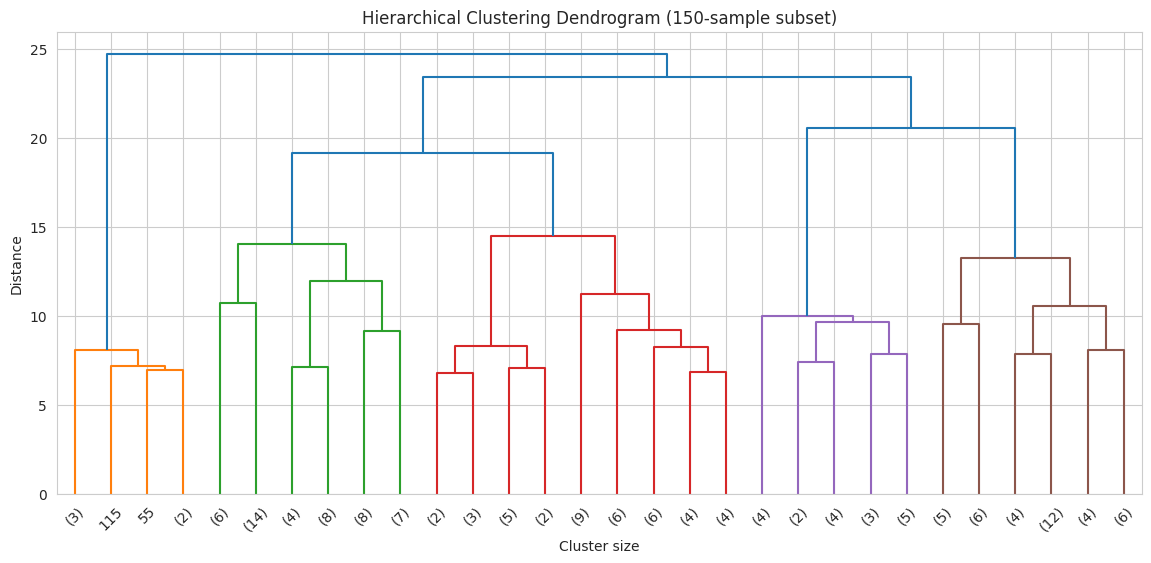

In [17]:
# Dendrogram on a sample (full 2000-row dendrogram is unreadable)
sample_idx = X_scaled.sample(150, random_state=RANDOM_STATE).index
Z = linkage(X_scaled.loc[sample_idx], method='ward')

plt.figure(figsize=(14,6))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title('Hierarchical Clustering Dendrogram (150-sample subset)')
plt.xlabel('Cluster size')
plt.ylabel('Distance')
plt.show()

## Step 6b — Cluster Visualization (PCA 2D Projection)

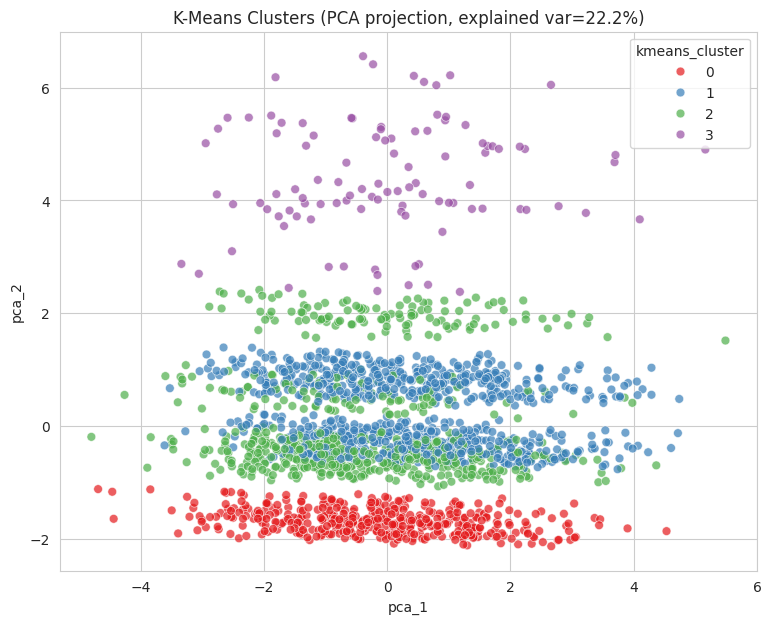

In [18]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)
df['pca_1'], df['pca_2'] = pca_coords[:,0], pca_coords[:,1]

plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='pca_1', y='pca_2', hue='kmeans_cluster', palette='Set1', s=40, alpha=0.7)
plt.title(f'K-Means Clusters (PCA projection, explained var={pca.explained_variance_ratio_.sum():.1%})')
plt.show()

## Step 7 — Cluster Interpretation

Profile each cluster by investment purpose, geographic distribution, loan behaviour, and demographics, then map to Parcl's recommended buyer segments (Global Investors, First-Time Buyers, Corporate Buyers, Luxury Investors).

In [19]:
profile = df.groupby('kmeans_cluster').agg(
    size=('client_id','count'),
    avg_age=('age','mean'),
    pct_company=('client_type', lambda x: (x=='Company').mean()*100),
    pct_investment_purpose=('acquisition_purpose', lambda x: (x=='Investment').mean()*100),
    pct_loan_applied=('loan_applied', lambda x: (x=='Yes').mean()*100),
    avg_satisfaction=('satisfaction_score','mean'),
    avg_num_purchases=('num_purchases','mean'),
    avg_total_spend=('total_spend','mean'),
    avg_price=('avg_price','mean'),
    avg_floor_area=('avg_floor_area','mean'),
    pct_office_units=('pct_office_units', 'mean'),
).round(2)
profile

,size,avg_age,pct_company,pct_investment_purpose,pct_loan_applied,avg_satisfaction,avg_num_purchases,avg_total_spend,avg_price,avg_floor_area,pct_office_units
kmeans_cluster,,,,,,,,,,,
0,423,55.35,0.0,0.00,0.00,3.10,3.61,1245917.78,347304.75,1148.36,0.15
1,833,56.64,0.0,21.13,28.21,2.99,3.69,1280203.83,349153.07,1152.63,0.15
2,641,54.36,0.0,62.87,71.45,3.02,3.62,1243605.83,344626.26,1140.92,0.15
3,103,47.12,100.0,34.95,41.75,3.07,3.70,1263753.49,344854.97,1142.98,0.15


In [20]:
# Top country per cluster
for cl in sorted(df['kmeans_cluster'].unique()):
    top_c = df[df['kmeans_cluster']==cl]['country'].value_counts().head(3)
    print(f"Cluster {cl} top countries:\n{top_c}\n")

Cluster 0 top countries:
country
Usa       324
Uk         18
Canada     17
Name: count, dtype: int64

Cluster 1 top countries:
country
Usa       642
Uk         44
Canada     33
Name: count, dtype: int64

Cluster 2 top countries:
country
Usa       492
Canada     32
Uk         28
Name: count, dtype: int64

Cluster 3 top countries:
country
Usa       80
France     5
Uk         5
Name: count, dtype: int64



In [21]:
# --- Auto-label clusters based on their profile (rank by avg_total_spend & pct_investment_purpose) ---
labels_map = {}
ranked = profile.sort_values('avg_total_spend', ascending=False)

for cl, row in profile.iterrows():
    if row['pct_company'] > 50:
        labels_map[cl] = 'Corporate Buyers'
    elif row['avg_total_spend'] == profile['avg_total_spend'].max() and row['avg_satisfaction'] >= profile['avg_satisfaction'].median():
        labels_map[cl] = 'Luxury Investors'
    elif row['pct_loan_applied'] > 50 and row['avg_age'] < profile['avg_age'].median():
        labels_map[cl] = 'First-Time Buyers'
    else:
        labels_map[cl] = 'Global Investors'

# Ensure all 4 business labels are used at most once each if k==4; otherwise fall back to generic naming
if OPTIMAL_K == 4 and len(set(labels_map.values())) < 4:
    fallback_names = ['Global Investors', 'First-Time Buyers', 'Corporate Buyers', 'Luxury Investors']
    labels_map = {cl: fallback_names[i] for i, cl in enumerate(profile.index)}

df['segment_name'] = df['kmeans_cluster'].map(labels_map)
print(labels_map)
df['segment_name'].value_counts()

{0: 'Global Investors', 1: 'First-Time Buyers', 2: 'Corporate Buyers', 3: 'Luxury Investors'}


segment_name
First-Time Buyers    833
Corporate Buyers     641
Global Investors     423
Luxury Investors     103
Name: count, dtype: int64

## Step 8 — Segment Visualizations

/tmp/ipykernel_591/2214997530.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='segment_name', y='total_spend', estimator=np.mean, ax=axes[1], palette='Set2')


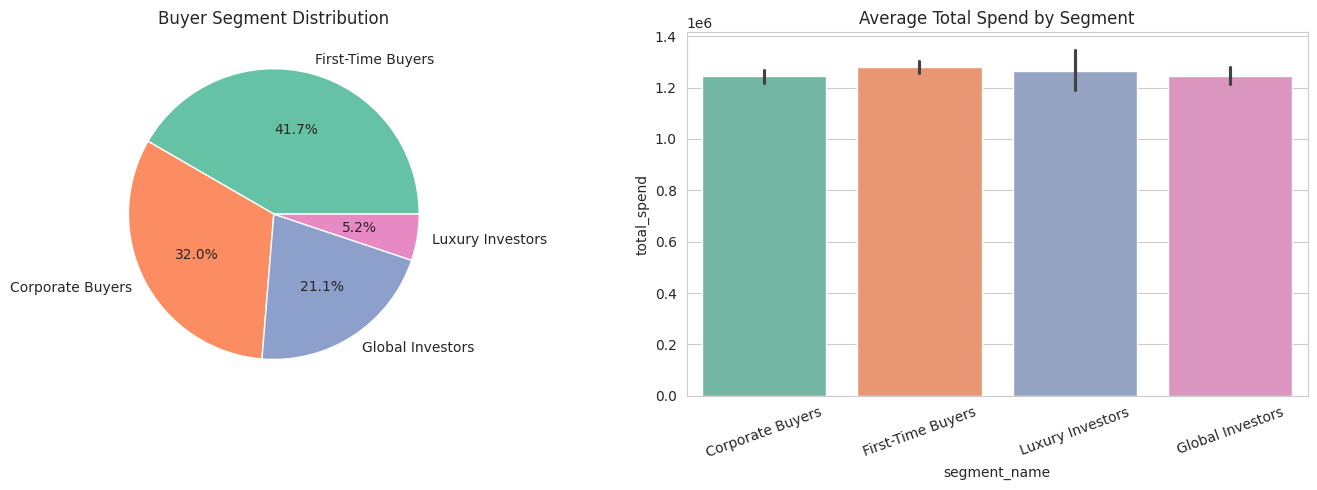

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df['segment_name'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0], colors=sns.color_palette('Set2'))
axes[0].set_ylabel('')
axes[0].set_title('Buyer Segment Distribution')

sns.barplot(data=df, x='segment_name', y='total_spend', estimator=np.mean, ax=axes[1], palette='Set2')
axes[1].set_title('Average Total Spend by Segment')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

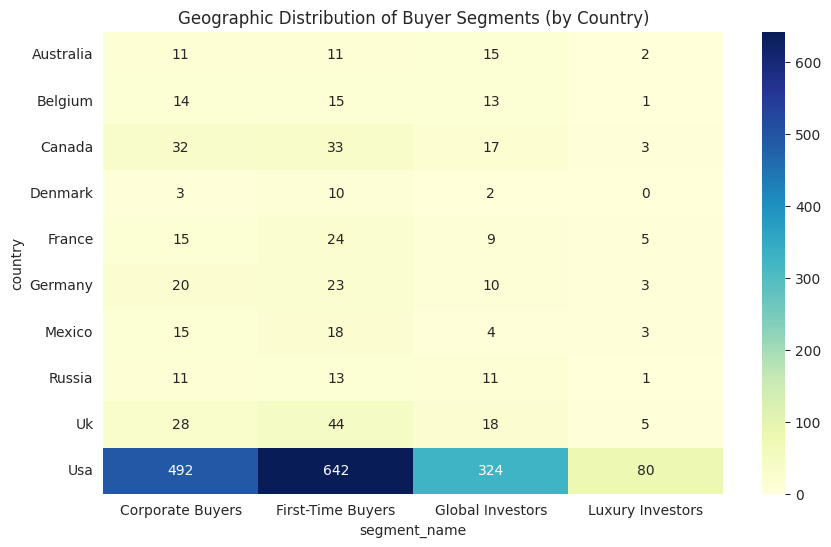

In [23]:
geo = df.groupby(['country','segment_name']).size().reset_index(name='count')
pivot = geo.pivot(index='country', columns='segment_name', values='count').fillna(0)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Geographic Distribution of Buyer Segments (by Country)')
plt.show()

## Step 9 — Export Results

Save the enriched, clustered dataset for use in the Streamlit dashboard (`streamlit_app.py` also recomputes this pipeline live, but exporting is useful for quick reuse/debugging).

In [24]:
output_cols = ['client_id','client_type','gender','country','region','age',
               'acquisition_purpose','satisfaction_score','loan_applied','referral_channel',
               'num_purchases','total_spend','avg_price','avg_floor_area','pct_office_units',
               'tenure_months','kmeans_cluster','hier_cluster','segment_name']
df[output_cols].to_csv('clustered_clients.csv', index=False)
print("Saved clustered_clients.csv with", df.shape[0], "rows")
df[output_cols].head()

Saved clustered_clients.csv with 2000 rows


,client_id,client_type,gender,country,region,age,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,num_purchases,total_spend,avg_price,avg_floor_area,pct_office_units,tenure_months,kmeans_cluster,hier_cluster,segment_name
0,C0001,Individual,F,Usa,California,57.0,Home,4,Yes,Website,4,1246764.72,311691.180000,983.885000,0.0,14.2,2,0,Corporate Buyers
1,C0002,Individual,M,Usa,California,63.0,Home,1,No,Website,5,1841095.93,368219.186000,1187.942000,0.0,23.3,1,1,First-Time Buyers
2,C0003,Individual,M,Usa,California,66.0,Home,4,Yes,Agency,5,1661457.59,332291.518000,1058.110000,0.0,15.2,1,0,First-Time Buyers
3,C0004,Individual,M,Usa,California,66.0,Home,5,No,Website,6,1608263.51,268043.918333,937.103333,0.0,18.2,1,1,First-Time Buyers
4,C0005,Company,M,Usa,California,49.0,Investment,5,No,Website,13,3653385.38,281029.644615,927.296154,0.0,15.2,3,1,Luxury Investors


## Conclusion

Clustering reveals distinct buyer archetypes within Parcl's client base — differentiated by investment purpose, financing reliance, spend level, and geography. These segments can drive targeted marketing (e.g. loan-assistance offers for First-Time Buyers, premium concierge service for Luxury Investors, bulk-unit deals for Corporate Buyers, and cross-border investment content for Global Investors).

**Next steps:** run `streamlit run streamlit_app.py` for the live, filterable dashboard version of this analysis.